In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [124]:
conn = sqlite3.connect('customer_churn.db')  

sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type ='table';
"""
table = pd.read_sql(sql_query,conn)

# create dataframe for each tanle
for table_name in table['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()




Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [ ]:

conn = sqlite3.connect('customer_churn.db')

for table_name in table['name']:
    print(f"nTable Name: {table_name}")
  
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print('columns:')
    print(columns['name'].tolist())


conn.close()

nTable Name: db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
nTable Name: db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
nTable Name: db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 2 Data Cleaning ##

In [127]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [128]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [129]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
# negative indexing
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)
# positive indexing
df_db_customer.drop(df_db_customer.columns[6:], axis = 1)

# without indexing
df_db_customer.drop(columns=['interests','pincode'], inplace = True)

In [ ]:
df_db_customer.rename(columns = {'name':'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [132]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [133]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [ ]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [135]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [ ]:
df_db_customer['gender'].unique()


array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [137]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Women':'Female','Men':'Male'})

In [138]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df_db_customer [df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [140]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [ ]:
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()



In [142]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [143]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [144]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [145]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [146]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [147]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [148]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [149]:
df_db_support.drop(columns = ['col_1','comment'], inplace = True)

In [150]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [151]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date']) 

In [152]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


## 3. Feature engineering and Data Analysis ##

In [154]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34


In [ ]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [156]:
df_db_subscription.head() 

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))


In [158]:
df.shape

(23, 20)

In [159]:
df_db_subscription['customerid'].nunique()

21

In [160]:
df_db_customer['customerid'].nunique()

21

In [161]:
df_db_support['customerid'].nunique()

7

In [162]:
df_db_support['customerid'].nunique()

7

In [163]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [164]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [165]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [ ]:
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))


In [168]:
df.to_csv('exported_churn_data.csv', index=False)

In [173]:
df.shape

(852, 21)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               852 non-null    object 
 1   subscription_start_date  852 non-null    object 
 2   subscription_type        852 non-null    object 
 3   renewal_date             852 non-null    object 
 4   plan_type                852 non-null    object 
 5   contract_type            852 non-null    object 
 6   cancellation_date        120 non-null    object 
 7   cancellation_reason      120 non-null    object 
 8   monthly_charges          852 non-null    float64
 9   cltv                     852 non-null    int64  
 10  churn_score              852 non-null    int64  
 11  churn_flag               852 non-null    int64  
 12  customer_name            852 non-null    object 
 13  country                  852 non-null    object 
 14  state                    8

In [175]:
date_col = ['subscription_start_date','renewal_date','cancellation_date','dob','complaint_date']

df[date_col] = df[date_col].apply(pd.to_datetime)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               852 non-null    object        
 1   subscription_start_date  852 non-null    datetime64[ns]
 2   subscription_type        852 non-null    object        
 3   renewal_date             852 non-null    datetime64[ns]
 4   plan_type                852 non-null    object        
 5   contract_type            852 non-null    object        
 6   cancellation_date        120 non-null    datetime64[ns]
 7   cancellation_reason      120 non-null    object        
 8   monthly_charges          852 non-null    float64       
 9   cltv                     852 non-null    int64         
 10  churn_score              852 non-null    int64         
 11  churn_flag               852 non-null    int64         
 12  customer_name            852 non-nul

## DATA ANALYSIS ##

In [177]:
df.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [178]:
churn_rate = df['churn_flag'].mean()*100
print("churn_flag = ", round(churn_rate,2), "%")

churn_flag =  14.08 %


In [ ]:
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  85.92 %


In [180]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [ ]:
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           13.33
1   Premium           15.65
2  Standard           13.65


In [182]:
churn_by_state = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct') 
print(churn_by_state)

               state  churn_rate_pct
0              Assam           21.21
1              Bihar           11.43
2       Chhattisgarh            3.70
3              Delhi           15.62
4                Goa           14.71
5            Gujarat           16.13
6            Haryana            7.41
7   Himachal Pradesh            9.38
8          Jharkhand           20.00
9          Karnataka           15.00
10         Kathmandu           13.04
11            Kerala           15.15
12    Madhya Pradesh           11.11
13       Maharashtra           12.82
14           Manipur           16.22
15         Meghalaya           27.27
16          Nagaland           21.74
17            Odisha            2.94
18            Punjab           18.92
19         Rajasthan           10.42
20        Tamil Nadu            8.82
21         Telangana           12.00
22           Tripura           13.79
23     Uttar Pradesh           17.50
24       Uttarakhand           14.29
25       West Bengal           10.71


In [183]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


In [184]:
churn_by_state = df.groupby('state').agg(
    Total_Revenue = ('monthly_charges','sum'),
    Total_count =('customerid','count'),
    Churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)))
print(churn_by_state)

                  Total_Revenue  Total_count  Churn_rate_pct
state                                                       
Assam                    547.23           33           21.21
Bihar                    532.34           35           11.43
Chhattisgarh             339.45           27            3.70
Delhi                    425.72           32           15.62
Goa                      512.78           34           14.71
Gujarat                  493.77           31           16.13
Haryana                  416.52           27            7.41
Himachal Pradesh         544.77           32            9.38
Jharkhand                373.36           25           20.00
Karnataka                590.02           40           15.00
Kathmandu                395.28           23           13.04
Kerala                   511.04           33           15.15
Madhya Pradesh           433.41           27           11.11
Maharashtra              600.57           39           12.82
Manipur                 

In [186]:
cbs = df.groupby('subscription_type').agg(
    Total_Revenue = ('monthly_charges','sum'),
    Total_count = ('customerid','count'),
    Churn_rate = ('churn_flag', lambda x: (round(x.mean()*100, 2))
)).reset_index()
cbs

,subscription_type,Total_Revenue,Total_count,Churn_rate
0,Organic,4037.37,270,11.85
1,Paid,5461.70,354,14.97
2,Refferal,3573.24,228,15.35


In [ ]:
arpu = df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 15.34


In [ ]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

        (df['cancellation_date'] - df['subscription_start_date']).dt.days,
        (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days) =', round(avg_tenure),0)

Avg Tenure (Days) = 1555 0


In [ ]:
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revrnue at Risk (Rs 'K') =",revenue_at_risk)

Revrnue at Risk (Rs 'K') = 1873.12


In [ ]:
Escalation_Rate = (df['escalations']=='Y').mean()*100
print('Escalation Rate = ', round(Escalation_Rate, 2),'%')

Escalation Rate =  11.97 %


In [ ]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print('avg_complaints =', round(avg_complaints,2))

avg_complaints = 0.81


In [ ]:
df['escalations'] = np.where(df['escalations'] == 'Y',1,0) # encoding string to int type

Corr_df = df[['escalations','churn_flag']].dropna()



Correlation = Corr_df['escalations'].corr(df['churn_flag']) 
print('correlation between esclation vs chrun is = ', round(Correlation,2))


correlation between esclation vs chrun is =  nan


In [213]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [ ]:
condition = [
    (df['churn_score'] <50),
    (df['churn_score'] >=50) & (df['churn_score'] <70),
    (df['churn_score'] >=70),
]

choices = ['low','med','high']

df['churn_risk'] = np.select(condition, choices,default = 'unkown')

In [215]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [216]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [217]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1950.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high


## 4. visualization using matplotlib ##


In [218]:
df_visual = df.copy()

In [219]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [220]:
df_visual.shape

(852, 23)

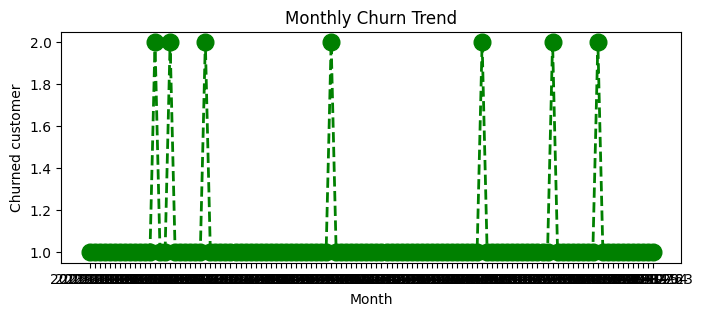

In [ ]:

df_visual['cancellation_date'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_date').size()

plt.figure(figsize = (8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color ='green', 
    marker = 'o', linestyle = 'dashed',
    linewidth =2,
    markersize = 12 )

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned customer')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

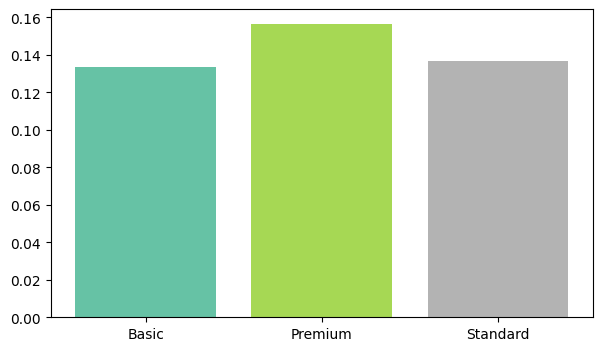

In [ ]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow', 'purple', 'blue'] #mannual
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan))) # automatic


plt.figure(figsize = (7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show


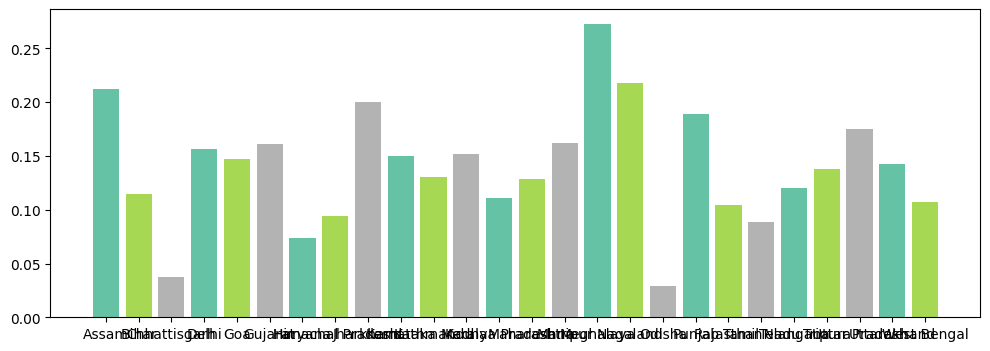

In [ ]:
churn_plan_state = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan_state.index, churn_plan_state.values, color = colors)
plt.show()

## Visualization using Seaborn ##

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [225]:
df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [226]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,NaN
1,1,0,91,1,0,Y
2,0,1,34,0,1,NaN
3,1,0,8,0,1,NaN
4,2,1,88,1,0,Y


In [227]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_encoded = df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag','churn_risk','escalations']]

categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

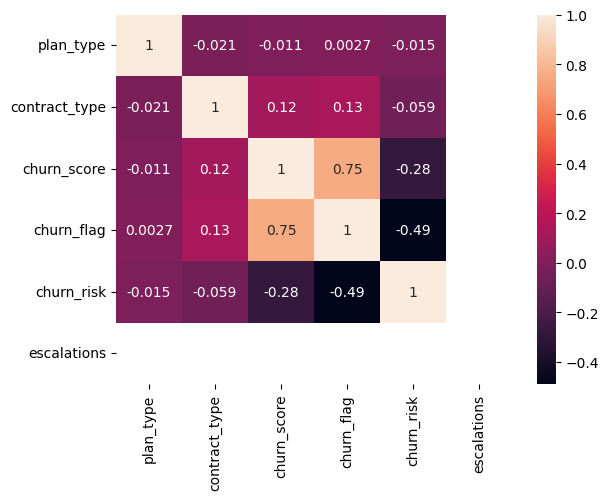

In [ ]:
sns.heatmap(df_encoded.corr(),annot = True)

In [ ]:
df_encoded = df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag','churn_risk','escalations']]

order_mapping = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [232]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


<Axes: >

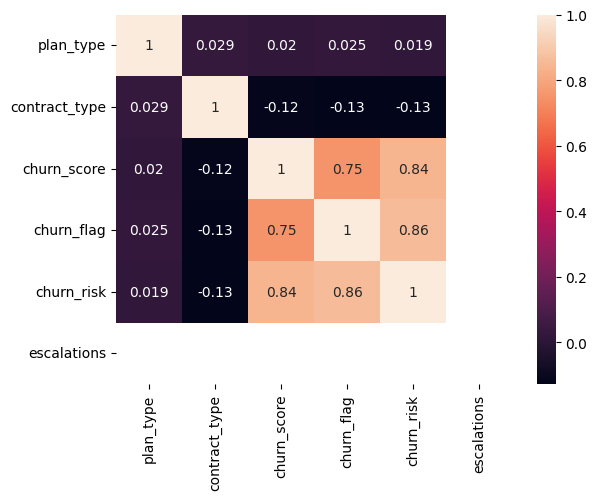

In [233]:
sns.heatmap(df_encoded.corr(),annot = True)

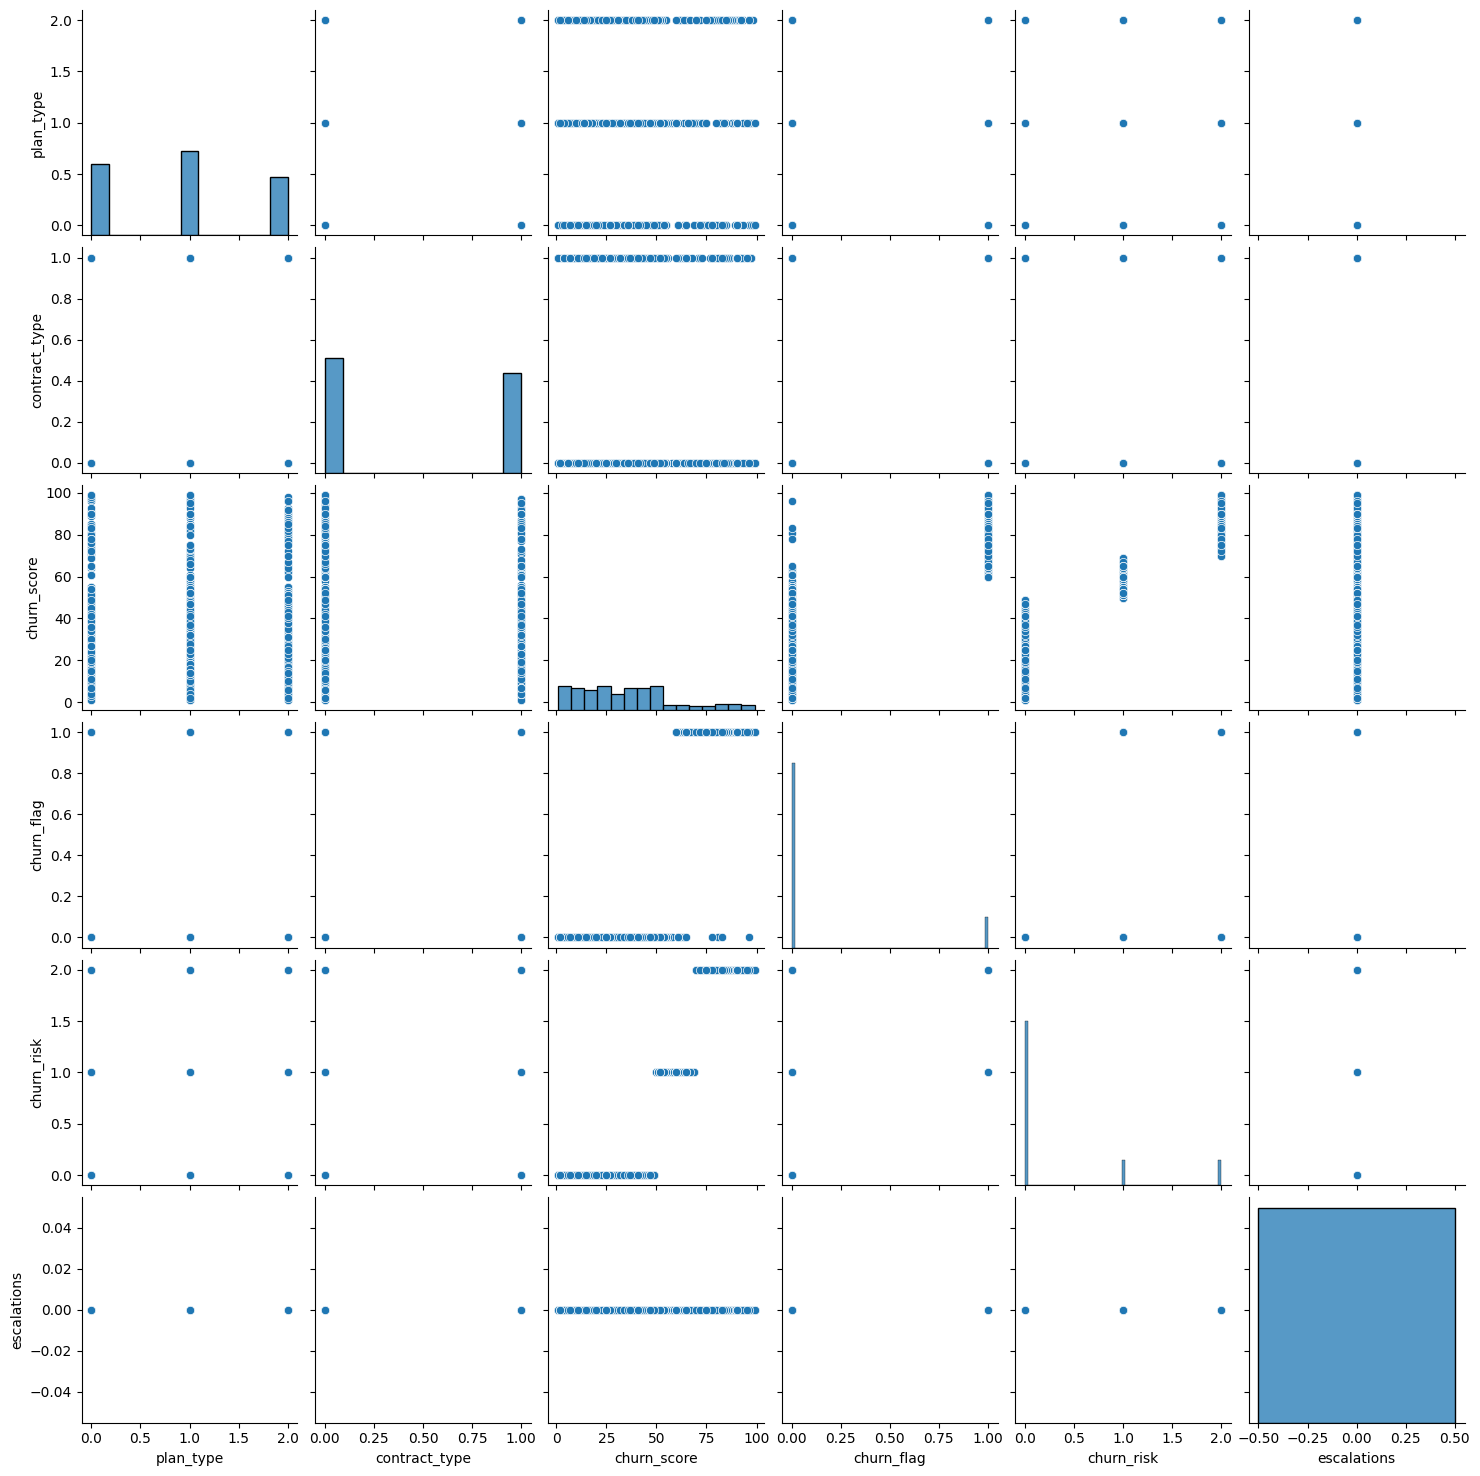

In [ ]:
sns.pairplot(df_encoded)

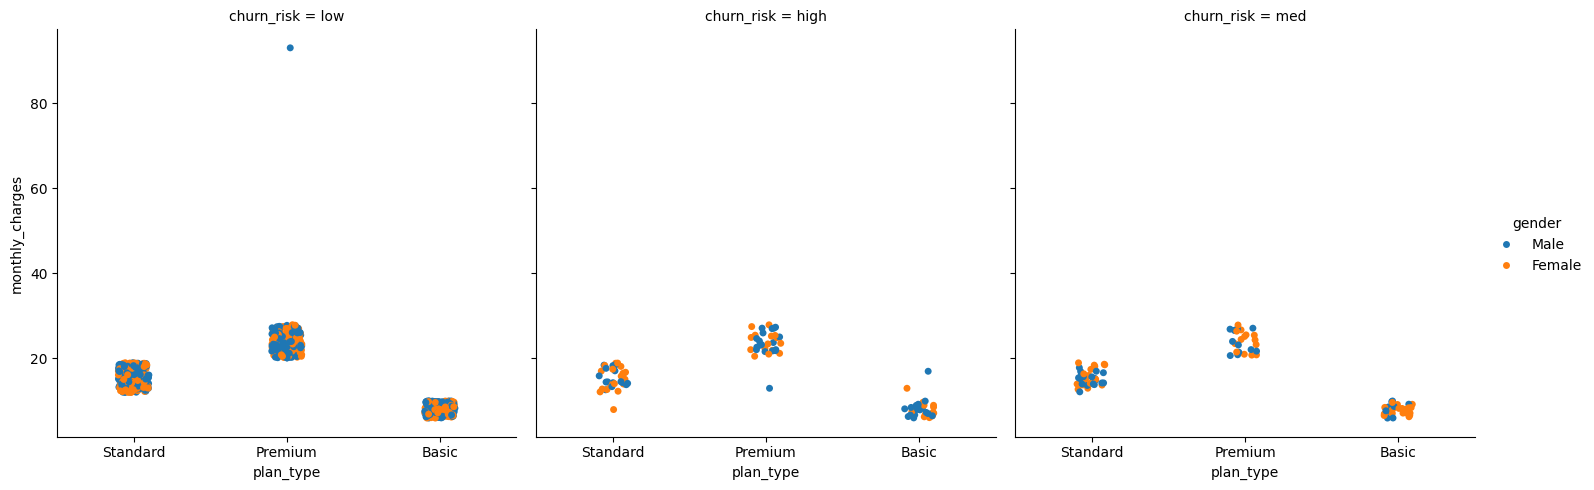

In [ ]:
sns.catplot(data = df_visual,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk')